In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

#Visualizar gráficas en el cuaderno
%matplotlib inline

#Velocidad de la luz
c=299792.458

#Para hacer la configuración de gráficas
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["font.size"] = 12

In [25]:
#Definiendo la función de Hubble
def E_func(z, Omega_m):
    return np.sqrt(Omega_m * (1 +z)**3 + (1 - Omega_m))

In [26]:
#Definiendo la distancia de luminosidad
def dist_luminosidad(z, Omega_m, H0):
    #Integral es de 1/E(z)
    integrando= lambda z_prime: 1.0 / E_func(z_prime, Omega_m)

    # quad devuelve (valor_integral, error_estimado). Solo queremos el valor [0].
    integral, error = quad(integrando, 0, z)
    
    # Formula: dL = (1+z) * (c/H0) * integral
    return (1 + z) * (c / H0) * integral

In [27]:
#Definiendo el mu teórico
def mu_teorico(z, Omega_m, H0):
    dL = dist_luminosidad(z, Omega_m, H0)
    # Evitamos logaritmo de 0
    if dL <= 0: return 0
    return 5 * np.log10(dL) + 25

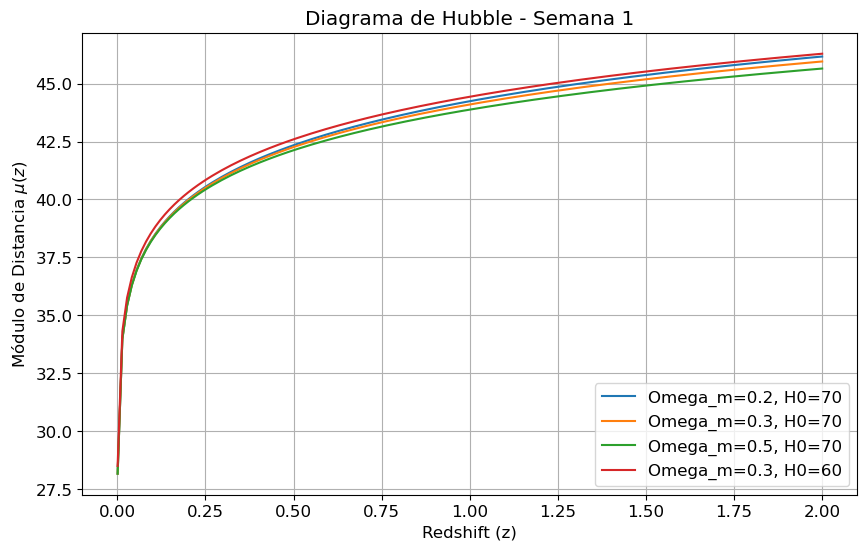

In [28]:
# 1. Crear un rango de redshifts (de 0.001 a 2)
z_vals = np.linspace(0.001, 2.0, 150)

# 2. Definir los modelos que queremos comparar (Omega_m, H0)
modelos = [
    (0.2, 70, 'Omega_m=0.2, H0=70'),
    (0.3, 70, 'Omega_m=0.3, H0=70'),
    (0.5, 70, 'Omega_m=0.5, H0=70'),
    (0.3, 60, 'Omega_m=0.3, H0=60'),
]

# 3. Graficar
plt.figure(figsize=(10, 6))

for Om, H0, etiqueta in modelos:
    # Calculamos mu para cada z en este modelo
    mu_vals = [mu_teorico(z, Om, H0) for z in z_vals]
    plt.plot(z_vals, mu_vals, label=etiqueta)

plt.xlabel('Redshift (z)')
plt.ylabel('Módulo de Distancia $\mu(z)$')
plt.title('Diagrama de Hubble - Semana 1')
plt.legend()
plt.grid(True)
plt.show()